# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [ ]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [ ]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

O Jena Climate é um dataset de domínio meteorológico ele reúne 14 variáveis ambientais diferentes medidas a cada 10 minutos, incluindo temperatura, pressão atmosférica, umidade relativa e direção do vento. O objetivo principal da base é servir como benchmark para prever o comportamento climático futuro (como a temperatura das próximas horas) com base no histórico recente. Ele é ideal para Redes Neurais Recorrentes (RNNs e LSTMs) porque possui alta resolução temporal, leituras sem interrupções e dependência sequencial entre os dados (o clima de agora é afetado pelo clima de minutos atrás), permitindo que a memória de longo prazo da rede capture padrões diários, sazonais e de tendências com precisão.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

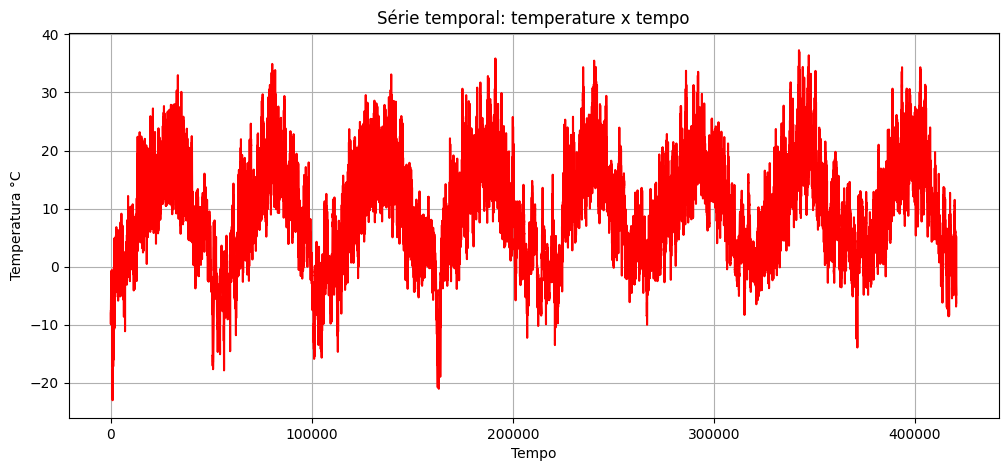

In [ ]:
from seaborn.palettes import color_palette
plt.figure(figsize=(12,5))

sns.lineplot(x=range(0, len(temperature)), y=temperature.flatten(), color='r')

plt.title("Série temporal: temperature x tempo")
plt.xlabel("Tempo")
plt.ylabel("Temperatura °C")
plt.grid(True)
plt.show()

In [ ]:
print(f"Total de amostras: {len(temperature)}")
print(f"\nTemperatura mínima: {temperature.min()} Temperatura máxima: {temperature.max()}")
print(f"Temperatura média: {temperature.mean():.4f} Desvio padrão: {temperature.std():.4f}")

Total de amostras: 420551

Temperatura mínima: -23.01 Temperatura máxima: 37.28
Temperatura média: 9.4501 Desvio padrão: 8.4234


O gráfico revela uma oscilação cíclica anual extremamente clara e bem definida. São visíveis cerca de 7 a 8 grandes ondas completas (vales e picos), que correspondem exatamente à mudança das estações do ano ao longo dos períodos de coleta. Os picos representam os meses de verão (onde a temperatura máxima) e os vales profundos correspondem aos meses de inverno (onde chega à mínima).

A série temporal é considerada estacionária em média, o que significa que não há uma tendência de subida ou descida contínua a longo prazo. A temperatura média se mantém estável durante todos os anos analisados.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [ ]:
temp_train, temp_test = temperature[:int(0.8*len(temperature))], temperature[int(0.8*len(temperature)):]

Não é adequado em um problema de previsão temporal aleaorizar a divisão dos dados já que o tempo segue uma ordem clara, ao embaralhar estaremos perdendo essa informação que pode ser útil ao modelo, como presença de sazonalidade entre outros aspectos temporais.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

temp_train_norm = scaler.fit_transform(temp_train)
temp_val_norm = scaler.transform(temp_val)
temp_test_norm = scaler.transform(temp_test)

print(f"Conjunto de treino: Máximo = {temp_train_norm.max()} Mínimo = {temp_train_norm.min()}")

Conjunto de treino: Máximo = 1.0 Mínimo = 0.0


A normalização é fundamental para o treinamento de redes neurais porque coloca os dados em uma escala unificada e restrita [0, 1]. Isso impede que valores numericamente muito altos saturem as funções de ativação e desestabilizem o cálculo dos gradientes. Na prática, dados normalizados garantem que o algoritmo de otimização tenham convergência muito mais rápido, tornando o treinamento mais estável, eficiente e menos propenso a travar em mínimos locais.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [ ]:
LOOKBACK = 30
def create_sequences(conjunto, lookback):
  x, y = [], []
  for i in range(len(conjunto) - lookback):
    x.append(conjunto[i:i + lookback])
    y.append(conjunto[i+lookback])

  return np.array(x), np.array(y)


X_train, y_train = create_sequences(temp_train_norm, LOOKBACK)
X_test, y_test = create_sequences(temp_test_norm, LOOKBACK)


print(f"Dimensões conjunto de treino: x_train: {X_train.shape} y_train: {y_train.shape}")
print(f"Dimensões conjunto de teste: x_test: {X_test.shape} y_test: {y_test.shape}")

Dimensões conjunto de treino: x_train: (336410, 30, 1) y_train: (336410, 1)
Dimensões conjunto de teste: x_test: (84081, 30, 1) y_test: (84081, 1)


Amostras: É a quantidade total de sequências (janelas históricas) que serão apresentadas à rede durante o treinamento.

Timesteps: É o tamanho da nossa janela temporal (lookback), indicando que a LSTM olhará para 30 passos de tempo no passado para tentar aprender o padrão.

Features: É o número de variáveis preditoras por passo de tempo. Como estamos lidando com uma série univariada, temos apenas 1 variável (a própria temperatura).

Para os conjuntos de saída (y):Retornam apenas (Amostras, 1) porque o objetivo do modelo é prever um único valor numérico contínuo: a temperatura exata do próximo passo de tempo imediatamente após a janela de 30 dias.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

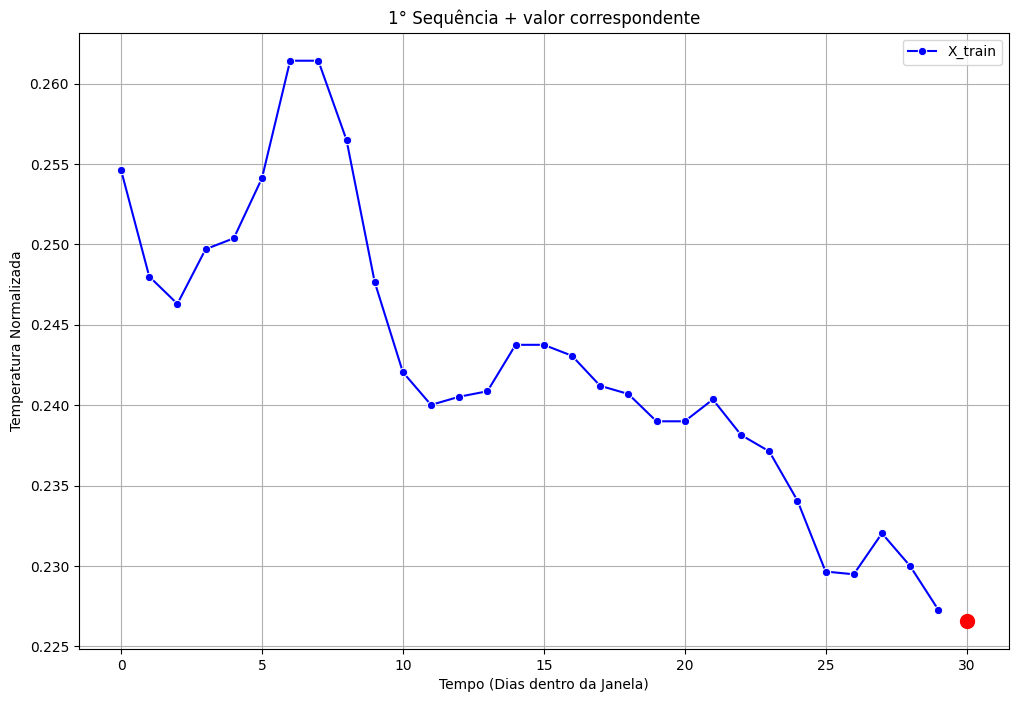

In [ ]:
plt.figure(figsize=(12,8))

sns.lineplot(x=range(30), y=X_train[0].flatten(), label="X_train", color='blue', marker='o')
plt.scatter(x=30, y=y_train[0][0], color='red', s=100, zorder=5, label="y_train")

plt.title("1° Sequência + valor correspondente")
plt.grid(True)
plt.xlabel("Tempo (Dias dentro da Janela)")
plt.ylabel("Temperatura Normalizada")
plt.show()

A cada passo de tempo, a LSTM atualiza seus estados internos. Esses estados funcionam como uma memória que decide quais informações passadas devem ser retidas (como a tendência de queda vista no final do gráfico) e quais devem ser descartadas.

Ao chegar no último ponto, a rede consolida todo o padrão histórico aprendido e passa essa informação para uma camada de saída, que gera uma previsão para o próximo passo. Durante o treinamento, essa previsão é comparada com o valor real de y_train[0] para calcular o erro e ajustar os pesos da rede, ensinando o modelo a acertar as próximas temperaturas.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Input

model = tf.keras.Sequential([
    Input(shape=(LOOKBACK,1)),
    LSTM(1),
    Dense(1)
])

model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

O total de parâmetros apresentado pelo summary do modelo são 14 parâmetros

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 0.0014 - val_loss: 1.0044e-04
Epoch 2/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 7.2088e-05 - val_loss: 3.9650e-05
Epoch 3/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 3.9343e-05 - val_loss: 2.6751e-05
Epoch 4/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 2.9368e-05 - val_loss: 2.1273e-05
Epoch 5/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 2.4471e-05 - val_loss: 1.8226e-05
Epoch 6/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 2.1528e-05 - val_loss: 1.6261e-05
Epoch 7/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 1.9559e-05 - val_loss: 1.4892e-05
Epoch 8/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 1.8161e-05 - val_loss: 1.3905e-05
Epoch 9/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 1.7138e-05 - val_loss: 1.3188e-05
Epoch 10/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.6384e-05 - val_loss: 1.2676e-05


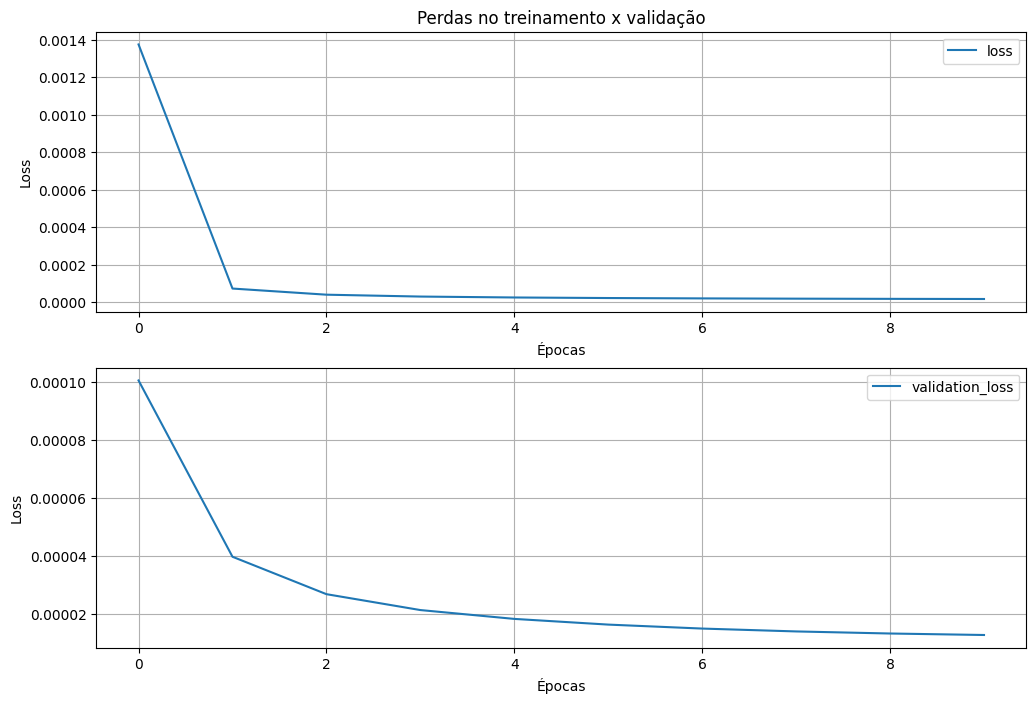

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(history.history['loss'], label='loss')

plt.title("Perdas no treinamento x validação")
plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.subplot(2,1,2)
plt.plot(history.history['val_loss'], label='validation_loss')

plt.legend()
plt.grid(True)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.show()

Ambas as curvas mostram um comportamento ideal de convergência rápida. Logo na primeira época, ocorre uma queda drástica no valor do erro (Loss), indicando que a LSTM aprendeu rapidamente os padrões principais da série temporal. A partir da segunda época, a redução do erro torna-se suave, estabilizando-se em valores extremamente baixos até a décima época.

Não há nenhuma evidência de overfitting ou problemas de generalização no modelo. Visto que a curva de erro se mantem constante, sem sofrer uma variação

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [ ]:
loss_evaluate = history.model.evaluate(X_test, y_test)

print(f"Loss MSE: {loss_evaluate:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.5816e-05
Loss MSE: 0.000016


Como os dados foram normalizados entre 0 e 1, o valor de 0.000012 é extremamente baixo, o que indica que, na média, as previsões da LSTM estão coladas nos valores reais da série temporal, demonstrando uma precisão alta.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


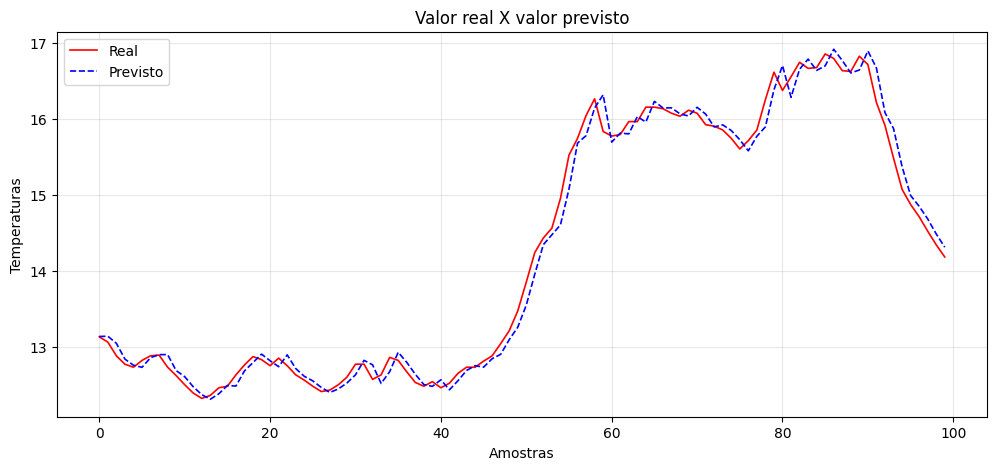

In [ ]:
y_norm_pred = model.predict(X_test)

y_pred_real = scaler.inverse_transform(y_norm_pred)
y_real = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,5))

plt.plot(y_real[:100], linewidth=1.2, color='r', label="Real")
plt.plot(y_pred_real[:100], linewidth=1.2,linestyle='--', color='b', label="Previsto")

plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Valor real X valor previsto")
plt.xlabel("Amostras")
plt.ylabel("Temperaturas")
plt.show()

As previsões demonstram coerência com os dados dados reais, durante toda a série é possível ver que a previsão se aproxima corretamente dos valores reais das temperaturas, sem demonstrar um deslocamento temporal inadequado e com poucos pontos de erro significativo.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [ ]:
model2 = tf.keras.Sequential([
    Input(shape=(LOOKBACK,1)),
    LSTM(10),
    Dense(1)
])

model2.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 8.0720e-04 - val_loss: 2.0150e-05
Epoch 2/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.8541e-05 - val_loss: 1.8457e-05
Epoch 3/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.4115e-05 - val_loss: 1.1749e-05
Epoch 4/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3752e-05 - val_loss: 1.0401e-05
Epoch 5/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3577e-05 - val_loss: 9.8787e-06
Epoch 6/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.3442e-05 - val_loss: 1.0107e-05
Epoch 7/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.3370e-05 - val_loss: 1.0142e-05
Epoch 8/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3324e-05 - val_loss: 1.0055e-05
Epoch 9/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - loss: 1.3284e-05 - val_loss: 9.9333e-06
Epoch 10/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - loss: 1.3247e-05 - val_loss: 9.8631e-06


In [ ]:
loss_evaluate_10lstm = history2.model.evaluate(X_test, y_test)

print(f"Loss MSE: {loss_evaluate_10lstm:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.2350e-05
Loss MSE: 0.000012


### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [ ]:
model3 = tf.keras.Sequential([
    Input(shape=(LOOKBACK,1)),
    LSTM(20),
    Dense(1)
])

model3.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history3 = model3.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 2.2518e-04 - val_loss: 2.3136e-05
Epoch 2/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.8691e-05 - val_loss: 2.1603e-05
Epoch 3/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 1.4316e-05 - val_loss: 1.1170e-05
Epoch 4/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.3810e-05 - val_loss: 9.9526e-06
Epoch 5/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3521e-05 - val_loss: 1.0353e-05
Epoch 6/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3374e-05 - val_loss: 1.0134e-05
Epoch 7/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.3313e-05 - val_loss: 9.9377e-06
Epoch 8/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.3267e-05 - val_loss: 9.8172e-06
Epoch 9/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3227e-05 - val_loss: 9.7686e-06
Epoch 10/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.3195e-05 - val_loss: 9.7463e-06


In [ ]:
loss_evaluate_20lstm = history3.model.evaluate(X_test, y_test)

print(f"Loss MSE: {loss_evaluate_20lstm:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2203e-05
Loss MSE: 0.000012


### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [ ]:
comp1 = pd.DataFrame({'Unidade LSTM': ['1','10','20'],
                      'Parmâmetros':[model.count_params(), model2.count_params(), model3.count_params()],
                      'MSE (teste)':[loss_evaluate, loss_evaluate_10lstm, loss_evaluate_20lstm],
                      'Tempo médio de treino':['56s','55s','64s']
                      })

display(comp1)

,Unidade LSTM,Parmâmetros,MSE (teste),Tempo médio de treino
0,1,14,0.000016,56s
1,10,491,0.000012,55s
2,20,1781,0.000012,64s


À medida que aumentamos a quantidade de unidades na camada LSTM (de 1 para 10, e depois para 20), o modelo torna-se significativamente mais complexo. Isso fica evidente pelo salto no número de Parâmetros, que vai de 14 para 491, chegando a 1781. O tempo de treino também reflete esse custo, subindo para 64 segundos no modelo maior.

A mudança de 1 para 10 unidades trouxe uma melhora perceptível no desempenho, reduzindo o erro (MSE) de 0.000014 para 0.000012. Isso mostra que 1 única unidade pode aumentar a capacidade do modelo de capturar padrões temporais dos dados.

No entanto, ao dobrar a complexidade de 10 para 20 unidades, o MSE permaneceu aproximadamente o mesmo (0.000012).

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [ ]:
model4 = tf.keras.Sequential([
    Input(shape=(15,1)),
    LSTM(10),
    Dense(1)
])

model4.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history4 = model4.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 0.0010 - val_loss: 2.7124e-05
Epoch 2/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 2.1441e-05 - val_loss: 1.5297e-05
Epoch 3/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.4365e-05 - val_loss: 1.0672e-05
Epoch 4/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3862e-05 - val_loss: 9.9774e-06
Epoch 5/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.3679e-05 - val_loss: 9.7244e-06
Epoch 6/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3510e-05 - val_loss: 1.0027e-05
Epoch 7/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.3418e-05 - val_loss: 1.0198e-05
Epoch 8/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.3359e-05 - val_loss: 1.0201e-05
Epoch 9/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3316e-05 - val_loss: 1.0108e-05
Epoch 10/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.3283e-05 - val_loss: 9.9975e-06


In [ ]:
loss_evaluate_10lstm_15lb = history4.model.evaluate(X_test, y_test)

print(f"Loss MSE: {loss_evaluate_10lstm_15lb:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2470e-05
Loss MSE: 0.000012


### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [ ]:
model5 = tf.keras.Sequential([
    Input(shape=(60,1)),
    LSTM(10),
    Dense(1)
])

model5.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history5 = model5.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 0.0016 - val_loss: 2.9652e-05
Epoch 2/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 2.4485e-05 - val_loss: 2.3100e-05
Epoch 3/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.5922e-05 - val_loss: 2.3495e-05
Epoch 4/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.4960e-05 - val_loss: 2.2645e-05
Epoch 5/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - loss: 1.4498e-05 - val_loss: 2.2084e-05
Epoch 6/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 59s 6ms/step - loss: 1.4159e-05 - val_loss: 1.8375e-05
Epoch 7/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step - loss: 1.3970e-05 - val_loss: 1.3463e-05
Epoch 8/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 1.3817e-05 - val_loss: 1.0987e-05
Epoch 9/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 1.3677e-05 - val_loss: 1.0222e-05
Epoch 10/10
9462/9462 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 1.3558e-05 - val_loss: 9.7738e-06


In [ ]:
loss_evaluate_10lstm_60lb = history5.model.evaluate(X_test, y_test)

print(f"Loss MSE: {loss_evaluate_10lstm_60lb:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.2272e-05
Loss MSE: 0.000012


### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [ ]:
comp2 = pd.DataFrame({'Janelas temporais': ['15','30','60'],
                      'Parmâmetros':[model4.count_params(), model.count_params(), model5.count_params()],
                      'MSE (Teste)':[loss_evaluate_10lstm_15lb, loss_evaluate, loss_evaluate_10lstm_60lb],
                      'Tempo médio de treino':['54s','56s','61s']
                      })

display(comp2)

,Janelas temporais,Parmâmetros,MSE (Teste),Tempo médio de treino
0,15,491,0.000012,54s
1,30,14,0.000016,56s
2,60,491,0.000012,61s


À medida que a janela temporal (lookback) aumenta de 15 para 60 amostras, o tempo médio de treinamento aumenta gradualmente (de 54s para 61s). Isso ocorre porque a LSTM precisa realizar mais passos matemáticos na sequência temporal

A janela de 15 amostras e a de 60 amostras atingiram o mesmo desempenho ideal (0.000012). Isso mostra que olhar apenas os últimos 15 passos já é suficiente para a LSTM capturar o padrão necessário para a previsão.

O aumento do erro na janela de 30 amostras (0.000014) deve-se ao fato de esse modelo específico estar usando menos neurônios que os modelos de 15 e 60.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Com base em todos os experimentos realizados, os fatores que mais influenciaram o desempenho e o custo computacional do modelo foram:

A Quantidade de Unidades LSTM: Este foi o fator de maior impacto no custo computacional. O aumento de neurônios eleva drasticamente o número de parâmetros treináveis (multiplicando o tamanho do modelo). Estruturas muito,  estruturas muito complexas (20 unidades) aumentam o tempo de processamento sem reverter em ganho de precisão.

O Tamanho da Janela Temporal: A janela temporal influenciou diretamente o tempo de processamento por época. Janelas maiores (60 amostras) exigem que a LSTM processe cadeias sequenciais mais longas a cada iteração, tornando o treino mais lento. Contudo, para este problema de temperatura, um histórico curto de 15 amostras já se mostrou autossuficiente para capturar a dinâmica dos dados.

Analisando o desempenho, o modelo com 10 unidades representa o melhor ponto de equilíbrio. Adicionar mais neurônios (20 unidades) aumentou a complexidade computacional e o tempo de treino sem trazer nenhuma grande melhora na precisão das previsões.

A janela temporal menor (15 amostras) provou ser a melhor escolha neste cenário. Ela entrega a precisão máxima (0.000012) com o menor custo computacional e tempo de execução mais rápido (54s), mostrando que um histórico muito longo (60) não trouxe ganho prático que justificasse o tempo extra de processamento.